# TD - Tropical Cyclones and Mortality
## Socioeconomic Impacts of Natural Disasters - Full Answers

**Guiding question:** Are the most powerful cyclones the deadliest? Or does income explain what wind speed cannot?

| Dataset | Description |
|---|---|
| `ibtracs_storms.csv` / `ibtracs_storms_land.csv` | IBTrACS global cyclone tracks - preprocessed (NOAA) |
| `emdat_tropical_cyclones_preprocessed.csv` | EM-DAT tropical cyclone events - preprocessed (CRED) |
| `country_gdp_income.csv` | World Bank income groups and GDP (most recent year, all countries) |


---
## Part 0 - Setting Up

### 0.1 - Import libraries

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import warnings
warnings.filterwarnings("ignore")

### 0.2 - Load Natural Earth coastlines

Land polygons from Natural Earth (110m resolution) used for all maps.
Drawn via geopandas on plain matplotlib axes - no cartopy required.

In [ ]:
# Natural Earth 110m land polygons - used for all maps
WORLD_URL = ("https://raw.githubusercontent.com/nvkelso/natural-earth-vector"
             "/master/geojson/ne_110m_land.geojson")
world = gpd.read_file(WORLD_URL)
print("World land polygons loaded:", world.shape)

World land polygons loaded: (127, 4)


### 0.3 - Load and preprocess IBTrACS

One row = one 6-hour position fix. We skip the unit header row.

Two storm-level datasets are built here for all subsequent analysis:
- **`storms`** - global peak per storm (for counting and mapping)
- **`storms_land`** - near-land peak per storm (for mortality correlation)

In [155]:
storms_land = pd.read_csv("data_final/ibtracs_storms_land.csv")
storms = pd.read_csv("data_final/ibtracs_storms.csv")

### 0.4 - Load and preprocess EM-DAT

In [156]:
# ── Load EM-DAT ────────────────────────────────────────────────────────────
em = pd.read_csv("data_final/emdat_tropical_cyclones_preprocessed.csv")

### 0.5 - Load country metadata and join to EM-DAT

Merge World Bank income group and GDP data via ISO 3-letter country code.

In [157]:
# ── Load country metadata and join to EM-DAT ───────────────────────────────
meta = pd.read_csv("data_final/country_gdp_income.csv")

em = em.merge(
    meta[["iso3", "income_group", "gdp_usd", "gdp_pc_usd"]],
    left_on="ISO", right_on="iso3", how="left"
)

print(f"Countries in meta: {len(meta)}")
print(f"EM-DAT events with income group: {em['income_group'].notna().sum()} / {len(em)}")

Countries in meta: 217
EM-DAT events with income group: 1984 / 2124


### 0.6 - Shared colour palettes

In [158]:
BASIN_COLORS = {
    "North Atlantic": "#e41a1c",   # North Atlantic
    "Western Pacific": "#377eb8",   # Western Pacific
    "Eastern Pacific": "#ff7f00",   # Eastern Pacific
    "North Indian": "#984ea3",   # North Indian
    "South Indian": "#4daf4a",   # South Indian
    "South Pacific": "#a65628",   # South Pacific
    "South Atlantic": "#999999",   # South Atlantic
}
ORDER = ["Low income", "Lower-middle income", "Upper-middle income", "High income"]
COLORS = {
    "Low income":          "#d73027",
    "Lower-middle income": "#fc8d59",
    "Upper-middle income": "#91bfdb",
    "High income":         "#4575b4",
}

---
## Part 1 - IBTrACS: The Physical Record

### 1.1 - How many tropical cyclones have been recorded since 1980?

IBTrACS records ~4 500 tropical cyclones since 1980 (one record per storm at its global peak). The Western Pacific generates the most (~30%), followed by the Eastern Pacific, South Indian, and North Atlantic. The North Atlantic - which receives most media attention - ranks 4th in raw storm count.


In [ ]:
# 1.1 - How many tropical cyclones have been recorded since 1980?
n_storms = len(storms)
n_basins = storms["BASIN"].value_counts()

print(f"Total tropical cyclones (IBTrACS, 1980–present): {n_storms:,}")
print(f"  - with near-land track: {len(storms_land):,}")
print(f"  - Period: {storms['SEASON'].min()} to {storms['SEASON'].max()}")
print(f"\nBreakdown by ocean basin:")
for basin, cnt in n_basins.items():
    print(f"  {basin}: {cnt:>4}  ({cnt/n_storms*100:.1f}%)")

Total tropical cyclones (IBTrACS, 1980–present): 4,488
  - with near-land track: 2,309
  - Period: 1980 to 2026

Breakdown by ocean basin:
  Western Pacific: 1372  (30.6%)
  Eastern Pacific:  905  (20.2%)
  South Indian:  768  (17.1%)
  North Atlantic:  741  (16.5%)
  South Pacific:  456  (10.2%)
  North Indian:  243  (5.4%)
  South Atlantic:    3  (0.1%)


### 1.2 - Where are tropical cyclones located?

Intense storms concentrate in the Western Pacific and North Indian Ocean, both regions with large lower-income coastal populations. The North Atlantic is well represented despite lower raw counts because storms there tend to be well-documented and often make landfall on densely populated coasts. Storm intensity and human vulnerability co-locate geographically, which already hints that the physical signal alone cannot explain mortality outcomes.


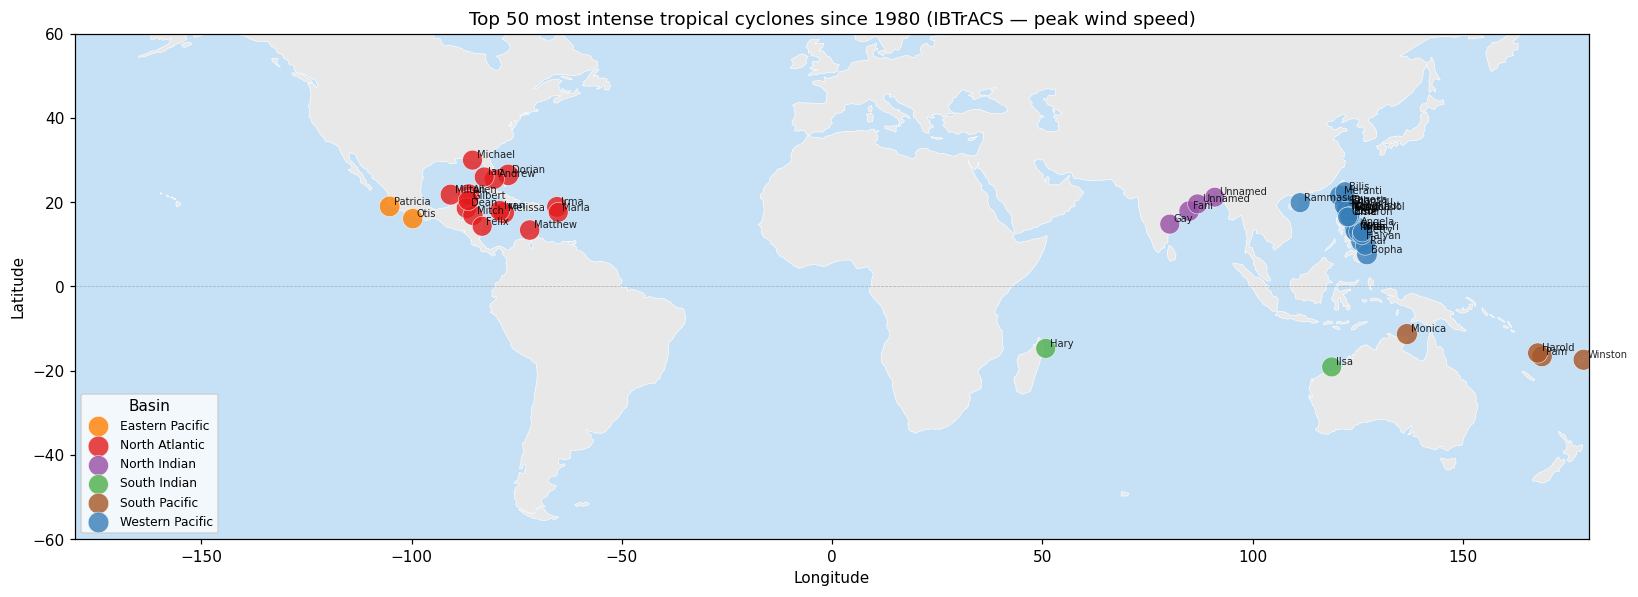

In [ ]:
# 1.2 - Where are tropical cyclones located?
# Map of the 50 most intense storms (by global peak wind speed), coloured by basin.
top50 = storms_land.nlargest(50, "USA_WIND")

fig, ax = plt.subplots(figsize=(15, 7))
world.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.4, zorder=1)
ax.set_facecolor("#c6e0f5")

for basin, grp in top50.groupby("BASIN"):
    color = BASIN_COLORS.get(basin, "grey")
    ax.scatter(grp["LON"], grp["LAT"],
               s=grp["USA_WIND"] * 1.2,
               color=color, alpha=0.8, edgecolors="white", linewidths=0.4,
               label=basin, zorder=3)
    for _, row in grp.iterrows():
        ax.text(row["LON"] + 1, row["LAT"] + 0.5,
                row["NAME"].title(), fontsize=6.5, alpha=0.85)
        
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 60)
ax.axhline(0, color="grey", lw=0.5, ls="--", alpha=0.5)
ax.set_xlabel("Longitude");  ax.set_ylabel("Latitude")
ax.set_title("Top 50 most intense tropical cyclones since 1980 (IBTrACS - peak wind speed)")
ax.legend(title="Basin", fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

### 1.3 - The most extreme cyclones

The most intense cyclones are overwhelmingly in the Western Pacific. Patricia (2015, Eastern Pacific) and Haiyan (2013, Western Pacific) stand at the top. Intensity in the Western Pacific is driven by very warm and deep sea surface temperatures, low wind shear, and large fetch distances.


Top 15 most intense cyclones (global peak, 1980–present):
    NAME  SEASON           BASIN  USA_WIND  USA_WIND_KMH
   LINDA    1997 Eastern Pacific     160.0         296.0
    IVAN    1997 Western Pacific     160.0         296.0
 GILBERT    1988  North Atlantic     160.0         296.0
    JOAN    1997 Western Pacific     160.0         296.0
     GAY    1992 Western Pacific     160.0         296.0
  HALONG    2019 Western Pacific     165.0         306.0
   ALLEN    1980  North Atlantic     165.0         306.0
   MAWAR    2023 Western Pacific     165.0         306.0
 BOLAVEN    2023 Western Pacific     165.0         306.0
 MELISSA    2025  North Atlantic     165.0         306.0
  HAIYAN    2013 Western Pacific     170.0         315.0
 MERANTI    2016 Western Pacific     170.0         315.0
    GONI    2020 Western Pacific     170.0         315.0
 SURIGAE    2021 Western Pacific     170.0         315.0
PATRICIA    2015 Eastern Pacific     185.0         343.0


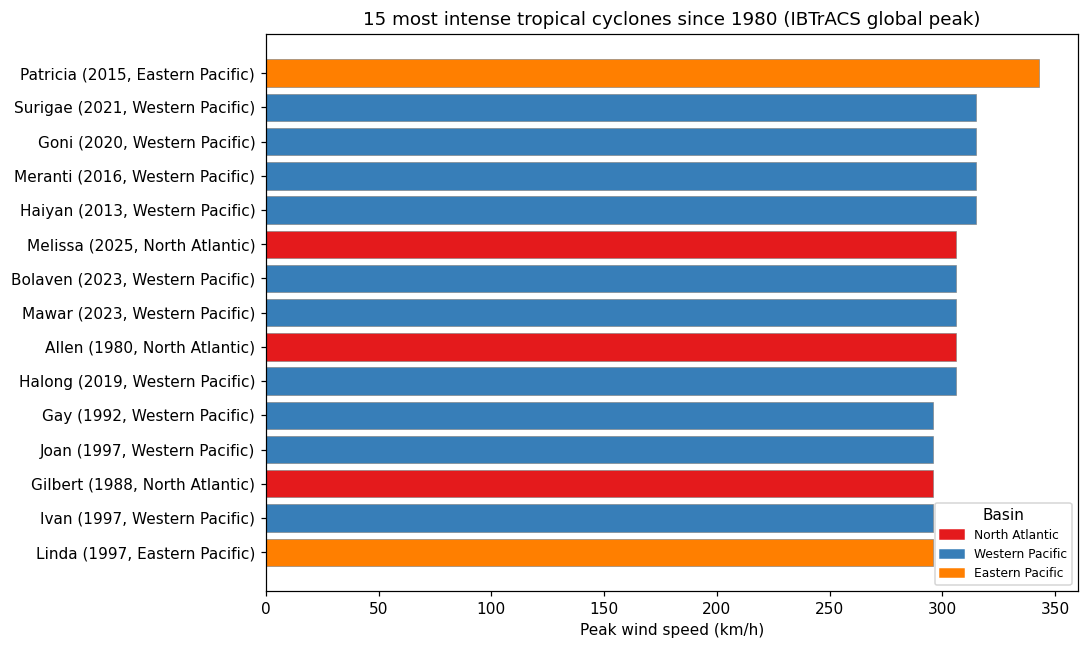

In [ ]:
# 1.3 - The most extreme cyclones
top15_wind = (storms.nlargest(15, "USA_WIND")
              [["NAME", "SEASON", "BASIN", "USA_WIND"]]
              .assign(USA_WIND_KMH=lambda d: (d["USA_WIND"] * 1.852).round(0))
              .sort_values("USA_WIND"))

print("Top 15 most intense cyclones (global peak, 1980–present):")
print(top15_wind.to_string(index=False))

# Chart
fig, ax = plt.subplots(figsize=(10, 6))
labels = (top15_wind["NAME"].str.title()
          + " (" + top15_wind["SEASON"].astype(str)
          + ", " + top15_wind["BASIN"] + ")")
colors = [BASIN_COLORS.get(b, "grey") for b in top15_wind["BASIN"]]
ax.barh(labels, top15_wind["USA_WIND_KMH"],
        color=colors, edgecolor="grey", linewidth=0.4)
ax.set_xlabel("Peak wind speed (km/h)")
ax.set_title("15 most intense tropical cyclones since 1980 (IBTrACS global peak)")
legend_els = [mpatches.Patch(color=v, label=k)
              for k, v in BASIN_COLORS.items()
              if k in top15_wind["BASIN"].values]
ax.legend(handles=legend_els, title="Basin", fontsize=8)
plt.tight_layout()
plt.show()

---
## Part 2 - EM-DAT: The Impact Record

### 2.1 - How many tropical cyclone events are recorded in EM-DAT?

EM-DAT records ~2 100 events post-1980. Western Pacific and North Indian Ocean dominate by count, consistent with IBTrACS. 

In [ ]:
# 2.1 - How many tropical cyclones are recorded in EM-DAT since 1980?
print(f"Total EM-DAT events (1980–present): {len(em):,}")
print(f"  Countries represented: {em['Country'].nunique()}")
print(f"\nBreakdown by region:")
print(em["Region"].value_counts().to_frame("events"))

Total EM-DAT events (1980–present): 2,124
  Countries represented: 119

Breakdown by region:
          events
Region          
Asia        1087
Americas     662
Oceania      184
Africa       171
Europe        20


### 2.2 - Mean and median deaths, affected persons, and damages per event

The mean is several times larger than the median for all three variables - the signature of a heavy-tailed distribution (meaning zero-concentrated distribution). A few catastrophic events pull the mean far above the typical event. The "average" cyclone is far less deadly than the overall mean implies.


In [ ]:
# 2.2 - Average deaths, people affected, and damages per event
impact_vars = {
    "Total Deaths":            "deaths",
    "Total Affected":          "people affected",
    "Total Damage ('000 US$)": "damage ('000 USD)",
}

print(f"{'Variable':<35} {'Mean':>12} {'Median':>12} {'Max':>15} {'N (>0)':>8}")
print("-" * 88)
for col, label in impact_vars.items():
    sub = em[em[col] > 0][col]
    print(f"{label:<35} {sub.mean():>12,.0f} {sub.median():>12,.0f}"
          f" {sub.max():>15,.0f} {len(sub):>8,}")

Variable                                    Mean       Median             Max   N (>0)
----------------------------------------------------------------------------------------
deaths                                       268           11         138,866    1,643
people affected                          547,694       20,000      29,622,000    1,690
damage ('000 USD)                      1,272,991       73,150     125,000,000    1,212


### 2.3 - Most deadly and most destructive events

The 15 deadliest events are almost entirely in lower-middle and low-income countries (Bangladesh, Myanmar, Honduras, India). Only one high-income country (Katrina in USA) appears on that list.

The 15 most destructive by economic damage tell the opposite story: 12 out of 15 are in the United States (plus Puerto Rico, a US territory). Japan and China account for the remaining two. Rich countries dominate the damage ranking because they have more capital at risk, better damage reporting, and insurance systems that record losses systematically.


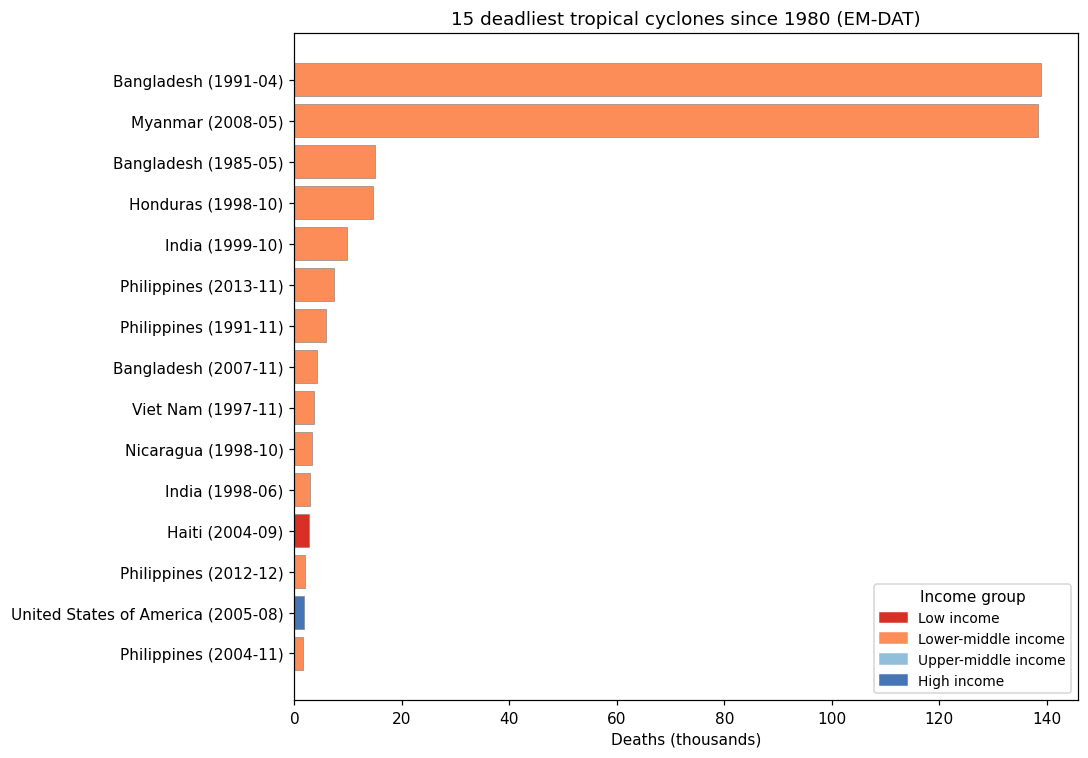

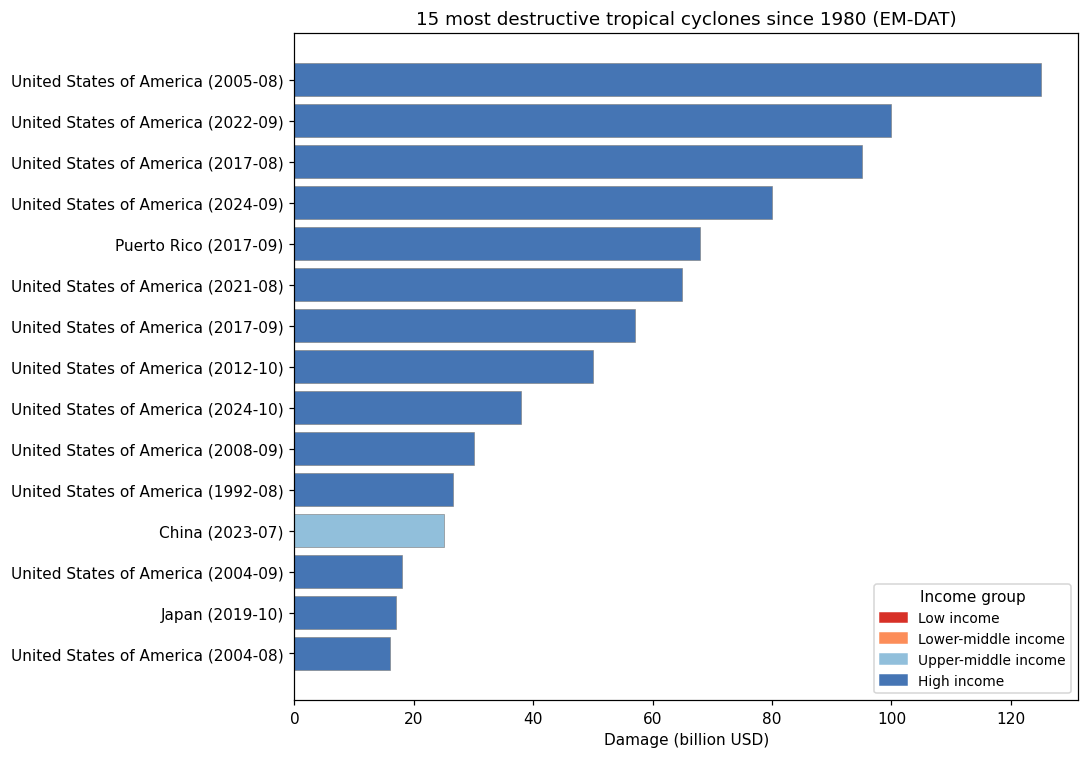

In [ ]:
# 2.3 - Most deadly and most destructive events

em_deaths = em[em["Total Deaths"] > 0].copy()
em_damage = em[em["Total Damage ('000 US$)"] > 0].copy()

for df, col, scale, xlabel, title in [
    (em_deaths, "Total Deaths",             1/1_000, "Deaths (thousands)",
     "15 deadliest tropical cyclones since 1980 (EM-DAT)"),
    (em_damage, "Total Damage ('000 US$)",  1/1e6,   "Damage (billion USD)",
     "15 most destructive tropical cyclones since 1980 (EM-DAT)"),
]:
    top = df.nlargest(15, col).copy()
    top["label"] = (top["Country"]
                    + " (" + top["Start Year"].astype(int).astype(str)
                    + "-" + top["Start Month"].astype(int).astype(str).str.zfill(2) + ")")
    top = top.sort_values(col)
    bar_colors = [COLORS.get(g, "#cccccc") for g in top["income_group"]]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top["label"], top[col] * scale,
            color=bar_colors, edgecolor="grey", linewidth=0.4)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    legend_els = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
    ax.legend(handles=legend_els, title="Income group", fontsize=9, loc="lower right")
    plt.tight_layout()
    plt.show()

---
## Part 3 - Coupling IBTrACS and EM-DAT

### 3.1 - How many storms are matched?

Matching on the `NAME_NORM` key (storm name + year + month, shared between both datasets) yields ~813 coupled storms. The match rate is roughly 35% of near-land IBTrACS storms.

Unmatched storms fall into three categories: (1) storms that hit uninhabited coasts and generated no EM-DAT record; (2) storms with no assigned name in one or both databases; (3) storms where the EM-DAT country-specific name differs from the WMO name in IBTrACS.


In [ ]:
# 3.1 - Coupling IBTrACS and EM-DAT: how many storms are matched?

matched = storms_land.merge(
    em[["NAME_NORM", "Start Year", "Total Deaths",
        "Total Affected", "Total Damage ('000 US$)"]],
    left_on=["NAME_NORM"],
    right_on=["NAME_NORM"],
    how="inner"
)


# Match IBTrACS (near-land) to EM-DAT by name + year

matched_deaths = matched[matched["Total Deaths"] > 0]

print(f"IBTrACS near-land storms:      {len(storms_land):,}")
print(f"EM-DAT named events:           {len(em):,}")
print(f"Matched storms (name + year):  {len(matched):,}")
print(f"  with at least 1 death:       {len(matched_deaths):,}")
print(f"\nMatch rate (vs IBTrACS land): {len(matched)/len(storms_land)*100:.1f}%")


IBTrACS near-land storms:      2,309
EM-DAT named events:           2,124
Matched storms (name + year):  1,490
  with at least 1 death:       1,160

Match rate (vs IBTrACS land): 64.5%


### 3.2 - What was Hurricane Katrina's maximum wind speed?

Katrina's near-land peak is 125 knots (~232 km/h). Nargis reached 115 knots (~213 km/h) near the Myanmar coast. Katrina was actually stronger at landfall, yet killed 75 times fewer people (1 833 vs. 138 366). Wind speed is a poor predictor of mortality. What determines the death toll is where the storm makes landfall and the capacity of the affected population to prepare, evacuate, and recover.


In [ ]:
# 3.2 - What was the maximum wind speed of Hurricane Katrina (USA, 2005)?
katrina_land = storms_land[
    (storms_land["NAME"] == "KATRINA") & (storms_land["SEASON"] == 2005)]
katrina_peak = storms[
    (storms["NAME"] == "KATRINA") & (storms["SEASON"] == 2005)]

if len(katrina_land):
    w_kt  = katrina_land["USA_WIND"].values[0]
    cat   = katrina_land["USA_SSHS"].values[0]
    print(f"Katrina (2005) - near-land peak wind:")
    print(f"  {w_kt:.0f} knots = {w_kt * 1.852:.0f} km/h  (Saffir-Simpson category {cat})")
else:
    print("Katrina not found near land (not in storms_land)")

if len(katrina_peak):
    w_pk = katrina_peak["USA_WIND"].values[0]
    print(f"  Global peak: {w_pk:.0f} knots = {w_pk * 1.852:.0f} km/h")

# Compare with Nargis (Myanmar 2008) - killed 75× more people
nargis_land = storms_land[
    (storms_land["NAME"] == "NARGIS") & (storms_land["SEASON"] == 2008)]
if len(nargis_land):
    w_n = nargis_land["USA_WIND"].values[0]
    print(f"\nNargis (2008) - near-land peak wind:")
    print(f"  {w_n:.0f} knots = {w_n * 1.852:.0f} km/h")
    print(f"\nKatrina was {'stronger' if w_kt > w_n else 'weaker'} than Nargis at landfall,")
    print(f"yet killed ~75× fewer people (1 833 vs 138 366).")

Katrina (2005) — near-land peak wind:
  125 knots = 232 km/h  (Saffir-Simpson category 4)
  Global peak: 150 knots = 278 km/h

Nargis (2008) — near-land peak wind:
  115 knots = 213 km/h

Katrina was stronger than Nargis at landfall,
yet killed ~75× fewer people (1 833 vs 138 366).


### 3.3 - Correlation: wind speed vs. deaths, affected, and damages

Results from Pearson correlation on log-transformed impact variables:

- Deaths : r ≈ 0.27. Weakly positive. Stronger storms tend to kill more, but scatter is enormous. Several moderate-intensity storms caused catastrophic mortality (Nargis, Gorky 1991).
- Affected : r ≈ 0.26. Similar pattern. Population density near the coast drives "affected" more than wind speed.
- Damage : r ≈ 0.34, the strongest of the three. Physical damage to infrastructure scales more predictably with wind energy. Rich countries also record higher absolute damage, which amplifies this correlation.

Wind speed explains only 7–12% of impact variance (r²). The missing explanatory variable is income and institutional capacity.


Impact variable                      r (Pearson)      n
--------------------------------------------------------
log(1 + Deaths)                            0.104  1,160
log(1 + Affected)                          0.119  1,171
log(1 + Damage '000 US$)                   0.179    892


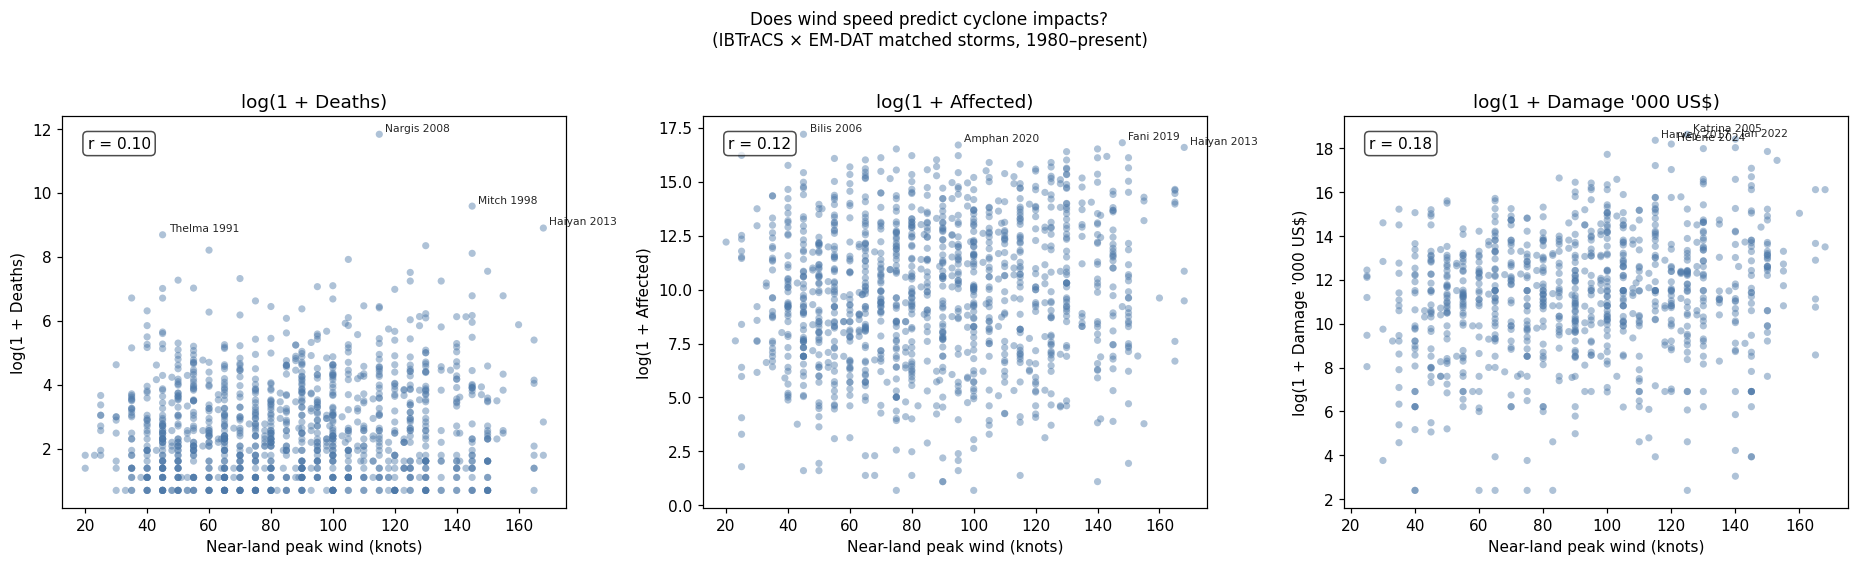

In [ ]:
# 3.3 - Correlations: wind speed vs. deaths, affected, and damages

impact_vars = [
    ("Total Deaths",   "log(1 + Deaths)"),
    ("Total Affected", "log(1 + Affected)"),
    ("Total Damage ('000 US$)",   "log(1 + Damage '000 US$)"),
]

print(f"{'Impact variable':<35} {'r (Pearson)':>12} {'n':>6}")
print("-" * 56)
for var, label in impact_vars:
    sub = matched.dropna(subset=[var, "USA_WIND"]).copy()
    sub = sub[sub[var] > 0]
    r   = sub["USA_WIND"].corr(np.log1p(sub[var]))
    print(f"{label:<35} {r:>12.3f} {len(sub):>6,}")

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (var, label) in zip(axes, impact_vars):
    sub = matched.dropna(subset=[var, "USA_WIND"]).copy()
    sub = sub[sub[var] > 0]
    r   = sub["USA_WIND"].corr(np.log1p(sub[var]))

    ax.scatter(sub["USA_WIND"], np.log1p(sub[var]),
               alpha=0.45, color="#4c78a8", s=22, edgecolors="none")

    # Label top outliers
    for _, row in sub.nlargest(4, var).iterrows():
        ax.annotate(row["NAME"].title() + f" {int(row['SEASON'])}",
                    xy=(row["USA_WIND"], np.log1p(row[var])),
                    fontsize=7, xytext=(4, 2), textcoords="offset points", alpha=0.85)

    ax.text(0.05, 0.95, f"r = {r:.2f}",
            transform=ax.transAxes, fontsize=10, va="top",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
    ax.set_xlabel("Near-land peak wind (knots)")
    ax.set_ylabel(label)
    ax.set_title(label)

plt.suptitle("Does wind speed predict cyclone impacts?\n(IBTrACS × EM-DAT matched storms, 1980–present)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

---
## Part 4 - The Role of Income

### 4.1 - 15 most deadly and most destructive: who is hit?

The two charts tell opposite stories. Deaths are dominated by lower-middle and low-income countries: Bangladesh, Myanmar, Honduras, the Philippines. The USA does not appear. Economic damage is dominated by the USA, which contributes multiple entries (Katrina 2005, Harvey 2017, Maria 2017, Sandy 2012). The core finding: in poor countries cyclones kill people; in rich countries they destroy capital.


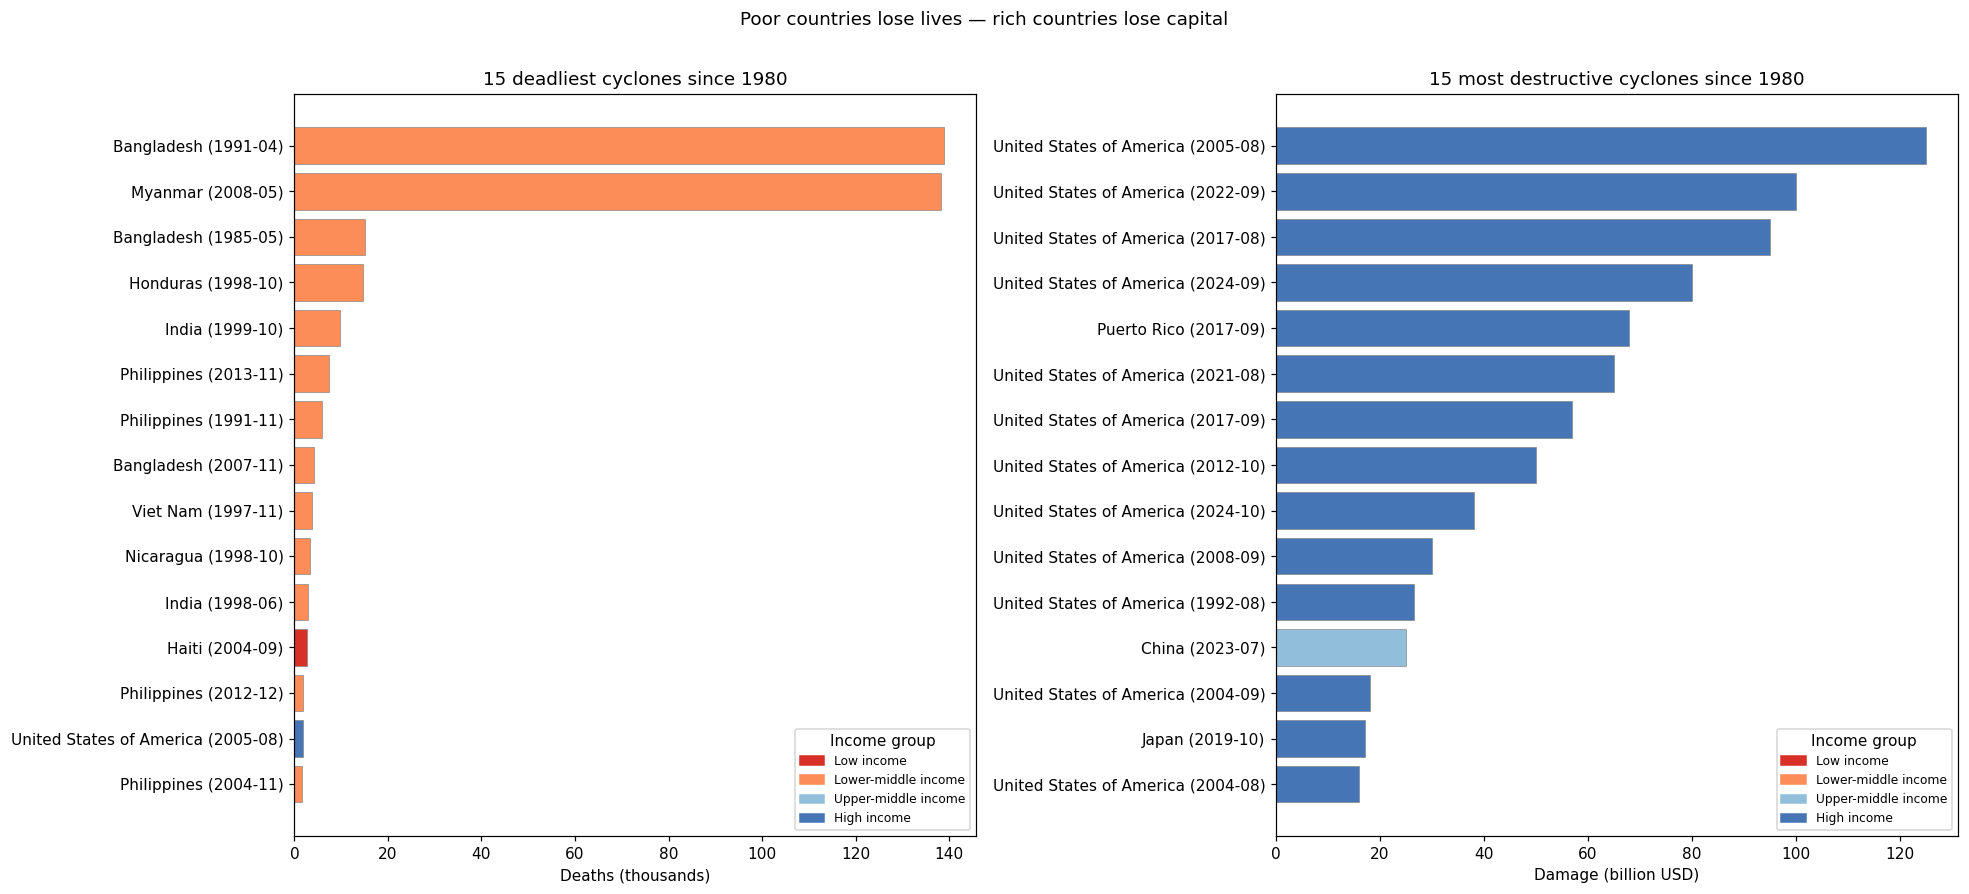

In [ ]:
# 4.1 - 15 most deadly and most destructive, coloured by income group

em_deaths = em[em["Total Deaths"] > 0].copy()
em_damage = em[em["Total Damage ('000 US$)"] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, df, col, scale, xlabel, title in [
    (axes[0], em_deaths, "Total Deaths",             1/1_000, "Deaths (thousands)",
     "15 deadliest cyclones since 1980"),
    (axes[1], em_damage, "Total Damage ('000 US$)",  1/1e6,   "Damage (billion USD)",
     "15 most destructive cyclones since 1980"),
]:
    top = df.nlargest(15, col).copy()
    top["label"] = (top["Country"]
                    + " (" + top["Start Year"].astype(int).astype(str)
                    + "-" + top["Start Month"].astype(int).astype(str).str.zfill(2) + ")")
    top = top.sort_values(col)
    colors = [COLORS.get(g, "#cccccc") for g in top["income_group"]]

    ax.barh(top["label"], top[col] * scale,
            color=colors, edgecolor="grey", linewidth=0.4)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    legend_els = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
    ax.legend(handles=legend_els, title="Income group", fontsize=8, loc="lower right")

plt.suptitle("Poor countries lose lives - rich countries lose capital",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 4.2 - GDP per capita vs. three impact dimensions

Deaths vs. GDP/cap: strong negative log-log slope. A tenfold increase in income is associated with roughly a hundredfold reduction in average deaths per event. Mechanisms include early warning systems, evacuation infrastructure, building codes, and access to healthcare.

People affected vs. GDP/cap: weaker gradient. Large middle-income countries (China, India, Bangladesh) expose very large populations independent of their income level. "Affected" conflates displacement and injury in ways that blur the income signal.

Damage vs. GDP/cap: positive slope ; richer countries record more damage per event, not less. This reflects higher asset density, better damage reporting, and functioning insurance markets, not greater physical destruction.


Countries in scatter: 17


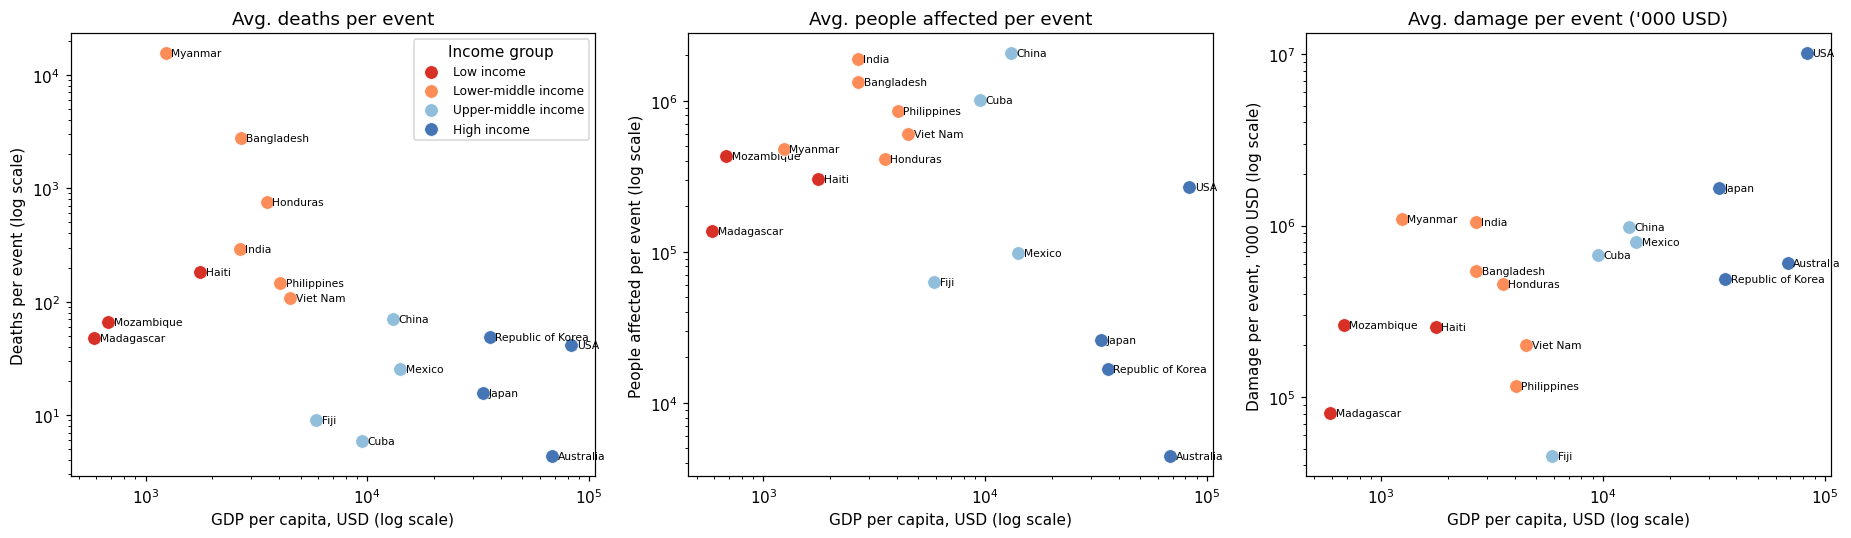

In [ ]:
# 4.2 - GDP per capita vs. three impact dimensions
# (countries with GDP per capita data)

em_class = em[em["income_group"].notna()].dropna(subset=["gdp_pc_usd"]).copy()

avg_impacts = (em_class
               .groupby(["Country", "income_group", "gdp_pc_usd"])
               .agg(
                   avg_deaths   =("Total Deaths",            lambda x: x[x > 0].mean()),
                   avg_affected =("Total Affected",          lambda x: x[x > 0].mean()),
                   avg_damage   =("Total Damage ('000 US$)", lambda x: x[x > 0].mean()),
               )
               .reset_index())

print(f"Countries in scatter: {len(avg_impacts)}")

impact_specs = [
    ("avg_deaths",   "Avg. deaths per event",            "Deaths per event (log scale)"),
    ("avg_affected", "Avg. people affected per event",   "People affected per event (log scale)"),
    ("avg_damage",   "Avg. damage per event ('000 USD)", "Damage per event, '000 USD (log scale)"),
]
#write USA instead of United States in the Country column
avg_impacts["Country"] = avg_impacts["Country"].str.replace("United States of America", "USA")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (col, title, ylabel) in zip(axes, impact_specs):
    sub_plot = avg_impacts.dropna(subset=[col]).copy()
    for group in ORDER:
        sub = sub_plot[sub_plot["income_group"] == group]
        ax.scatter(sub["gdp_pc_usd"], sub[col],
                   color=COLORS[group], s=80, label=group,
                   edgecolors="white", linewidths=0.5, zorder=3)
        for _, row in sub.iterrows():
            ax.text(row["gdp_pc_usd"] * 1.06, row[col],
                    row["Country"].split(",")[0], fontsize=7, va="center")
    ax.set_xscale("log");  ax.set_yscale("log")
    ax.set_xlabel("GDP per capita, USD (log scale)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[0].legend(title="Income group", fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

---
## Part 5 - Temporal Comparison: 2005–2014 vs. 2015–2024

### 5.1–5.3 - Summary statistics

Deaths: the 2005–2014 decade is dominated by one catastrophic event - Nargis (2008, Myanmar, 138 000 deaths). The 2015–2024 period shows lower peaks, consistent with improved early warning systems in the most exposed countries.

Damages: the 2015–2024 period records higher total damage.

Storm counts: slight increase in tropical cyclone count in the merged dataset, but could be driven by improved matching and reporting rather than a true increase in storm frequency. No clear upward trend in total IBTrACS counts across either period.


In [ ]:
# 5.1-5.3 - Summary table: 2005–2014 vs. 2015–2024
p1 = em[(em["Start Year"] >= 2005) & (em["Start Year"] <= 2014)]
p2 = em[(em["Start Year"] >= 2015) & (em["Start Year"] <= 2024)]

for label, df in [("2005-2014", p1), ("2015-2024", p2)]:
    deaths = df["Total Deaths"].sum()
    damage = df["Total Damage ('000 US$)"].sum() / 1e6  # billion USD
    n      = len(df)
    print(f"{label}: {n:,} events | Deaths: {deaths:,.0f} | Damage: {damage:.1f} bn USD")


2005-2014: 527 events | Deaths: 172,273 | Damage: 395.1 bn USD
2015-2024: 601 events | Deaths: 14,717 | Damage: 838.1 bn USD


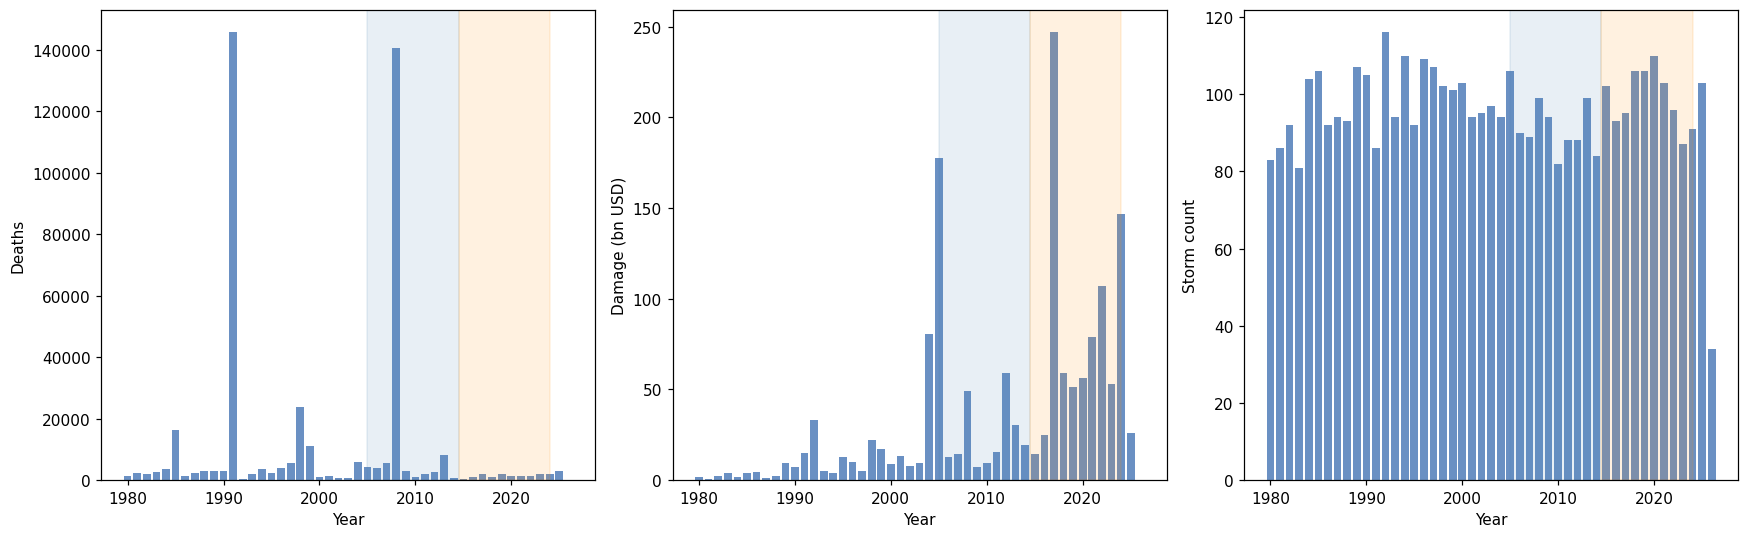

In [172]:
# Visual comparison: annual deaths / damages / storm counts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

annual_deaths  = em.groupby("Start Year")["Total Deaths"].sum()
annual_damage  = em.groupby("Start Year")["Total Damage ('000 US$)"].sum() / 1e6
annual_storms  = storms.groupby("SEASON").size()

for ax, series, ylabel in zip(
        axes,
        [annual_deaths, annual_damage, annual_storms],
        ["Deaths", "Damage (bn USD)", "Storm count"]):
    ax.bar(series.index, series.values, color="#4575b4", alpha=0.8)
    ax.axvspan(2005, 2014.5, alpha=0.12, color="steelblue")
    ax.axvspan(2014.5, 2024, alpha=0.12, color="darkorange")
    ax.set_ylabel(ylabel); ax.set_xlabel("Year")

plt.tight_layout()
plt.show()


---
## Part 6 - Discussion

### 6.1 — Inequality of impact

The data establish a robust pattern of unequal impact by income group.

Deaths fall sharply with GDP per capita (Parts 2, 3, 4). This is primarily an inequality of **vulnerability**, not exposure. Lower-income countries face similar or lower storm counts than richer countries (Part 1), yet suffer catastrophically more deaths. The mechanisms are institutional: early warning, evacuation, housing quality, healthcare - not geographic position.

Economic damage rises with income (Part 4.2). This is an inequality of **asset exposure**: rich countries have more capital at risk.

This questions the narrative of first the "naturality" of cyclone mortality as there is a low correlation between storm intensity and mortality. And of the valuation of damage, because deadliest storms are not the most damaging, questioning the relevance of monetary damage as a welfare metric.

Early-warning systems really seem to be making a difference in reducing mortality, as the 2015–2024 period shows fewer catastrophic death tolls than 2005–2014. 

---

### 6.2 — Potential implications for aid allocation and adaptation investment

**1. What metric should guide aid allocation?** Capital destroyed, deaths, people affected. Do a GDP metric could better reflect welfare loss even with the drawbacks of GDP ? 

**2. Isolating hazard is misleading.** The low correlation between wind speed and mortality suggests that the hazard itself is not the main driver of welfare loss. Both vulnerability and exposure matter, even more than the physical intensity of the storm. Aid frameworks that focus on the hazard rather than vulnerability and exposure will systematically under-resource the poorest affected populations.

**3. Potential extension for adaptation.** Similar questions arise for adaptation investment. Where should (public) resources be priorised? In dynamic territories with an important exposure due to investment, infrastructure, economic dynamism, or in more static territories with high vulnerability but lower exposure? 